In [1]:
import pandas as pd
from tqdm import tqdm
from sentence_transformers import CrossEncoder
from random import random
import matplotlib.pyplot as plt
import numpy as np


e:\repos\pessoal\redem-index\studies\fake_news\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_res = pd.read_excel(
    r"E:/repos/pessoal/redem-index/studies/fake_news/data/df_train.xlsx"
)

In [3]:
lies = [
    "Em nome da democracia, o Brasil acaba de ressuscitar os campos de concentração nazistas. Vídeo do ginásio da Polícia Federal comparado a campos de concentração nazistas",
    "Bolsonaro é o anticristo.",
    "Em nome da democracia o Brasil acaba de ressuscitar os campos de concentração nazista",
    "Ginásio da polícia federal é um gulag comunista",
    "Jair Bolsonaro foi condenado nos EUA e investigado pelo FBI por fraudar o cartão de vacinação contra Covid-19",
    "Boulos  está entre os dez deputados que mais aprovaram projetos na atual legislatura.",
    "Única responsabilidade do governo federal na concessão da Enel é a assinatura do contrato.",
    "Houve mais residências sem luz em São Paulo do que na Flórida após o furacão Milton.",
    " O ISS de João Pessoa seja menor que o de São Paulo.",
    "Eduardo Olivetto foi nomeado apenas na gestão de Ricardo Nunes.",
    "Guarda Civil Metropolitana deixou de realizar rondas para garantir a segurança das escolas",
    "São Paulo não está entre as cinco melhores cidades para negócios",
    "Policia Federal não apurou o destino dos presentes recebidos por Lula e Dilma",
    "Helicópteros das Forças Armadas não conseguiram alcançar a região devido ao mau tempo, enquanto aeronaves de civis como o empresário Luciano Hang estão atuando em missões de resgate e ajuda humanitária",
    "o ministro do Supremo Tribunal Federal Alexandre de Moraes interferiu no resultado das eleições presidenciais de 2022.",
    "Militares americanos no território brasileiro. Ações seriam uma forma de o governo Lula retribuir uma suposta interferência de Joe Biden que teria garantido sua vitória nas eleições de 2022",
    "Reportagem da Gazeta do Povo junto com a alegação de que a vacina da AstraZeneca fez “explodir” os casos de doenças cardíacas entre jovens.",
    "nota técnica do Ministério da Saúde ampliou o acesso ao aborto no Brasil",
    "mudança de sexo em crianças com verba da União",
    "PEC das Praias privatizara o litoral brasileiro",
    "Lei Rouanet (lei nº 8.313/1991) em 2023,  governo federal liberou  R$ 16 bilhões para artistas no fim do ano passado.",
    "empresas utilizam fetos abortados para fabricar cosméticos, especialmente após a divulgação do PL 1.904/2024, conhecido como “PL do Aborto”. Existe uma indústria mundial liderada por George Soros que depende de fetos humanos para produzir tais produtos",
    "uma idosa morreu nos ginásios da polícia federal",
    # CORONA
    "o isolamento vertical não propaga o vírus",
    "a cloroquina combate o coronavirus",
    "a quarentena de pessoas fora da idade de risco não contem a progragação do virus",
    "a quarentena não contem a progragação do virus",
    "hidroxicloroquina combate o coronavirus",
    "infectar metade de toda a população vai conter a propagação",
    "hospitais emitem atestados de obitos falsos do coranovirus",
    "medidas de isolamento não são eficazes para conter o vírus",
    "o isolamento social é ineficaz ou desnecessário",
    "medidas de isolamento não são eficazes",
    "a imprensa mente ou manipula informações sobre a pandemia",
    "a cloroquina combate o coronavírus",
    "o coranavirus tem propagação lenta",
    "a oms mente ou age por interesses políticos",
    "a china criou ou espalhou o vírus propositalmente",
    "imunidade natural do coronavirus",
    "remédio eficaz contra o coronavírus, ",
    "osmar terra é medico especializado",
    "david uip  é a favor da  hidroxicloroquina",
    "h1n1 foi mais letal que o coronavirus",
    "banco mundial diz que brasil combate bem o coronavirus",
]

In [4]:
cross_encoder = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

In [5]:
df_res.head()

,Unnamed: 0,date,screen_name,text,likes_count,comment_count,user_id,pub_id,analisado,is_fn
0,0,2023-12-31 23:29:46.000,Dandara Tonantzin,Que 2024 seja um ano de grandes feitos e reali...,1375.0,42.0,507629575,1.795624e+16,0.0,0.0
1,1,2023-12-31 23:25:44.000,Katarina Feitoza,"Que 2024 venha com amor e paz, permitindo que ...",1140.0,60.0,463726350,1.803634e+16,0.0,0.0
2,2,2023-12-31 23:23:34.000,Fred Linhares,Desejamos um Feliz Ano Novo pra vocês. Que sej...,0.0,126.0,3968408902,1.804343e+16,0.0,0.0
3,3,2023-12-31 23:22:17.000,Célio Studart,É… ganhou a cor branca! Que venha a paz! Feliz...,1962.0,153.0,327375969,1.840697e+16,0.0,0.0
4,4,2023-12-31 23:21:16.000,Erika Hilton,Meu 2023 não caberia em apenas uma retrospecti...,46753.0,1278.0,1280403287,1.797451e+16,0.0,0.0


In [6]:
df_res.columns

Index(['Unnamed: 0', 'date', 'screen_name', 'text', 'likes_count',
       'comment_count', 'user_id', 'pub_id', 'analisado', 'is_fn'],
      dtype='object')

In [ ]:
import numpy as np

def softmax(x):
    shifted_x = x - np.max(x, axis=-1, keepdims=True)  # Shift for numerical stability
    exp_x = np.exp(shifted_x)                          # Exponentiate shifted values
    sum_exp_x = np.sum(exp_x, axis=-1, keepdims=True) # Sum of exponentials
    return exp_x / sum_exp_x                           # Normalize to get probabilities

def minmax(x):
    return (x - x.min()) / (x.max() - x.min())


def predict_cross_encoder(post: str, lies: list[str]) -> list[tuple[str, float]]:
    scores = cross_encoder.predict([(post, lie) for lie in lies])
    return sorted(zip(lies, scores), key=lambda x: x[1], reverse=True)


df = df_res[df_res['analisado'] == 1].reset_index(drop=True)


X_train = []
y_train = []

X_test = []
y_test = []
pbar = tqdm(range(0, len(df)))
for i, row in df.iterrows():
    res = predict_cross_encoder(row["text"], lies)

    res_vector = softmax([score for _, score in res])

    # adicionar outras features
    # res_vector = np.append(res_vector, [row['min_distance_2'], row['distance_score'] ])


    is_fn = row["is_fn"]
    if is_fn == 0.5:
        is_fn = 1

    split = .8

    if is_fn == 1:
        split = .6
        
    if random() >= split:
        X_test.append(res_vector)
        y_test.append(is_fn)
    else:
        X_train.append(res_vector)
        y_train.append(is_fn)
    pbar.update(1)
pbar.close()

100%|██████████| 1798/1798 [23:21<00:00,  1.28it/s]


In [8]:
print(f"{sum(y_test)} positives in test; ({sum(y_train)}) in train.")

124.0 positives in test; (170.0) in train.


# TEST SVM

  0%|          | 0/99 [00:00<?, ?it/s]e:\repos\pessoal\redem-index\studies\fake_news\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\repos\pessoal\redem-index\studies\fake_news\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
100%|██████████| 99/99 [00:08<00:00, 11.94it/s]


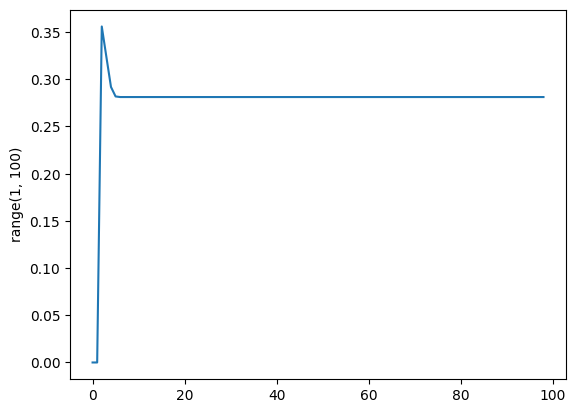

In [9]:
from sklearn import svm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)


precisions = []
for t in tqdm(range(1, 100)):
    clf = svm.SVC(kernel="poly", class_weight={0: 0.5, 1:t})
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    precisions.append(precision_score(y_test, y_pred))


plt.plot(precisions)
plt.ylabel(range(1,100))
plt.show()

In [21]:
clf = svm.SVC(kernel="poly", class_weight={0: 0.5, 1: 2.7})
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
precisions.append(precision_score(y_test, y_pred))

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7142857142857143
Precision: 0.48214285714285715
Recall: 0.21774193548387097
Classification Report:
               precision    recall  f1-score   support

         0.0       0.75      0.91      0.82       317
         1.0       0.48      0.22      0.30       124

    accuracy                           0.71       441
   macro avg       0.62      0.56      0.56       441
weighted avg       0.67      0.71      0.67       441

Confusion Matrix:
 [[288  29]
 [ 97  27]]


# PRedict

In [22]:
df_to_predict = df_res[df_res['analisado'] == 0].reset_index(drop=True)

In [ ]:

all_vectors = []
c = 0
for i, row in tqdm(df_to_predict.iterrows()):
    encoded = predict_cross_encoder(row['text'], lies)

    res_vector = [score for _, score in encoded ]

    all_vectors.append(res_vector)

    if c == 1000:
        break

    c += 1

res = clf.predict(all_vectors)


In [174]:
for i,r in enumerate(res):
    df_to_predict.loc[i, 'cross_encoder_results'] = r

In [175]:
df_to_predict.to_excel('10_cross_encoder_predicted.xlsx')